<a href="https://colab.research.google.com/github/BrunoGisbert/ProjetMMC/blob/main/3bp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

gamma: 0.010078170157197206
c2: 3.9405225931666834
c3: -2.9798426168397363
c4: 2.97025732279608
lambda: 2.0570142911717664
k: 3.187229431680047
Period in days: 180.14525767200638


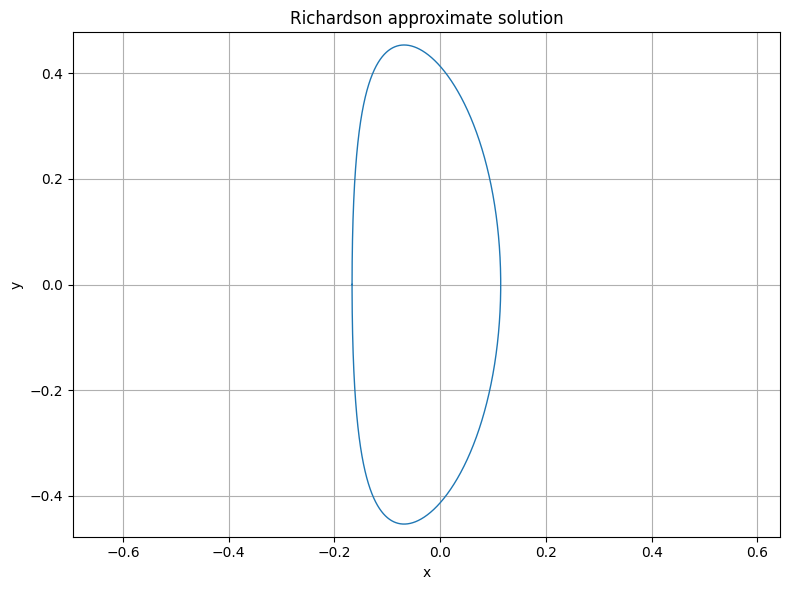

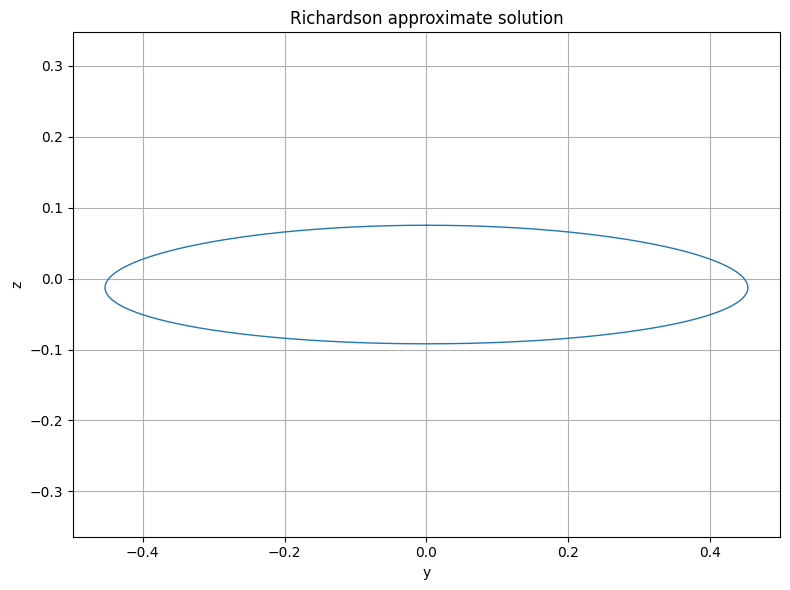

First approximation: [ 1.00839580e+00  0.00000000e+00  7.58160256e-04  0.00000000e+00
  9.87718589e-03 -0.00000000e+00]


In [16]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

mu = 3.04036e-6
# Calculation of distance from L2 to smaller primary in non-dimensional units (1 AU = 1)
def func(x):
    return x**5 + (3 - mu)*x**4 + (3 - 2*mu)*x**3 - mu*x**2 - 2*mu*x - mu

x0 = 0.01

solution = fsolve(func, x0)
gamma = solution[0]
print("gamma:", gamma)

# Setting up the third order approximation (Richardson 1980)
c2 = 1/gamma**3 * (mu + (1 - mu)*(gamma / (gamma + 1))**3)
c3 = 1/gamma**3 * -(mu + (1 - mu)*(gamma / (gamma + 1))**4)
c4 = 1/gamma**3 * (mu + (1 - mu)*(gamma / (gamma + 1))**5)

print("c2:", c2)
print("c3:", c3)
print("c4:", c4)

coeffs = [1, 0, c2 - 2, 0, -(c2 - 1)*(1 + 2*c2)]
roots = np.roots(coeffs)
lambda1 = roots[3].real
print('lambda:',lambda1)

k = (2*lambda1) / (lambda1**2 + 1 - c2)
print('k:',k)

d1 = (3*lambda1**2)/k * (k*(6*lambda1**2 - 1) - 2*lambda1)
d2 = (8*lambda1**2)/k * (k*(11*lambda1**2 - 1) - 2*lambda1)
d21 = -c3/(2*lambda1**2)
a21 = (3*c3*(k**2 - 2))/(4*(1 + 2*c2))
a22 = (3*c3)/(4*(1 + 2*c2))
a23 = -(3*c3*lambda1)/(4*k*d1) * (3*k**3*lambda1 - 6*k*(k - lambda1) + 4)
a24 = -(3*c3*lambda1)/(4*k*d1) * (2 + 3*k*lambda1)
b21 = -(3*c3*lambda1)/(2*d1) * (3*k*lambda1 - 4)
b22 = (3*c3*lambda1)/d1
b31 = 3/(8*d2) * (8*lambda1*(3*c3*(k*b21 - 2*a23) - c4*(2 + 3*k**2)) + (9*lambda1**2 + 1 + 2*c2)*(4*c3*(k*a23 - b21) + k*c4*(4 + k**2)))
b32 = 1/(d2) * (9*lambda1*(c3*(k*b22 + d21 - 2*a24) - c4) + (3/8)*(9*lambda1**2 + 1 + 2*c2)*(4*c3*(k*a24 - b22) + k*c4))
d31 = (3/(64*lambda1**2))*(4*c3*a24 + c4)
d32 = (3/(64*lambda1**2))*(4*c3*(a23 - d21) + c4*(4 + k**2))
a31 = -(9*lambda1)/(4*d2) * (4*c3*(k*a23 - b21) + k*c4*(4 + k**2)) + ((9*lambda1**2 + 1 - c2)/(2*d2)) * (3*c3*(2*a23 - k*b21) + c4*(2 + 3*k**2))
a32 = -1/(d2) * (((9*lambda1)/4)*(4*c3*(k*a24 - b22) + k*c4) + 1.5*(9*lambda1**2 + 1 - c2)*(c3*(k*b22 + d21 - 2*a24) - c4))
a1 = -1.5*c3*(2*a21 + a23 + 5*d21) - (3/8)*c4*(12 - k**2)
a2 = 1.5*c3*(a24 - 2*a22) + (9/8)*c4
s1 = (1/(2*lambda1*(lambda1*(1 + k**2) - 2*k))) * (1.5*c3*(2*a21*(k**2 - 2) - a23*(k**2 + 2) - 2*k*b21) - (3/8)*c4*(3*k**4 - 8*k**2 + 8))
s2 = (1/(2*lambda1*(lambda1*(1 + k**2) - 2*k))) * (1.5*c3*(2*a22*(k**2 - 2) + a24*(k**2 + 2) + 2*k*b22 + 5*d21) + (3/8)*c4*(12 - k**2))
l1 = a1 + 2*lambda1**2*s1
l2 = a2 + 2*lambda1**2*s2
Delta = lambda1**2 - c2
a = 1.49598e8
Az = 125000/(gamma * a)
Ax = np.sqrt((-Delta - l2*Az**2)/l1)
w2 = s1*Ax**2 + s2*Az**2
print('Period in days:',1/((1 + w2) * lambda1) *365.2563)

tau1 = np.linspace(0,2*np.pi,10001)

# The Richardson approximation
x = a21*Ax**2 + a22*Az**2 - Ax*np.cos(tau1) + (a23*Ax**2 - a24*Az**2)*np.cos(2*tau1) + (a31*Ax**3 - a32*Ax*Az**2)*np.cos(3*tau1)
y = k*Ax*np.sin(tau1) + (b21*Ax**2 - b22*Az**2)*np.sin(2*tau1) + (b31*Ax**3 - b32*Ax*Az**2)*np.sin(3*tau1)
z = Az*np.cos(tau1) + d21*Ax*Az*(np.cos(2*tau1) - 3) + (d32*Az*Ax**2 - d31*Az**3)*np.cos(3*tau1)

u = Ax*np.sin(tau1) - 2*(a23*Ax**2 - a24*Az**2)*np.sin(2*tau1) - 3*(a31*Ax**3 - a32*Ax*Az**2)*np.sin(3*tau1)
v = k*Ax*np.cos(tau1) + 2*(b21*Ax**2 - b22*Az**2)*np.cos(2*tau1) + 3*(b31*Ax**3 - b32*Ax*Az**2)*np.cos(3*tau1)
w = -Az*np.sin(tau1) - 2*d21*Ax*Az*np.sin(2*tau1) - 3*(d32*Az*Ax**2 - d31*Az**3)*np.sin(3*tau1)

plt.figure(figsize=(8, 6))
plt.plot(x, y, linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Richardson approximate solution')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(y, z, linewidth=1)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Richardson approximate solution')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

x0 = gamma*x[0] + 1 - mu + gamma
y0 = gamma*y[0]
z0 = gamma*z[0]
u0 = gamma*lambda1*(1 + w2)*u[0]
v0 = gamma*lambda1*(1 + w2)*v[0]
w0 = gamma*lambda1*(1 + w2)*w[0]

X0 = [x0, y0, z0, u0, v0, w0]
print('First approximation:',np.array(X0))

In [17]:
# Equations of motion + STM variational equations for CR3BP
def cr3bp_equations(t, state_stm):
    x, y, z, vx, vy, vz = state_stm[:6]
    # Distances to primaries
    r1 = np.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2 + z**2)
    # Accelerations in rotating frame
    ddx = 2*vy + x - (1 - mu)*(x + mu)/r1**3 - mu*(x - (1 - mu))/r2**3
    ddy = -2*vx + y - (1 - mu)*y/r1**3 - mu*y/r2**3
    ddz = - (1 - mu)*z/r1**3 - mu*z/r2**3

    # Compute partial derivatives for variational equations
    Uxx = 1 - (1 - mu)/r1**3 * (1 - 3*(x + mu)**2/r1**2) - mu/r2**3 * (1 - 3*(x - (1 - mu))**2/r2**2)
    Uyy = 1 - (1 - mu)/r1**3 * (1 - 3*y**2/r1**2)          - mu/r2**3 * (1 - 3*y**2/r2**2)
    Uzz =    - (1 - mu)/r1**3 * (1 - 3*z**2/r1**2)          - mu/r2**3 * (1 - 3*z**2/r2**2)
    Uxy = 3*((1 - mu)*(x + mu)*y/r1**5 + mu*(x - (1 - mu))*y/r2**5)
    Uxz = 3*((1 - mu)*(x + mu)*z/r1**5 + mu*(x - (1 - mu))*z/r2**5)
    Uyz = 3*((1 - mu)*y*z/r1**5 + mu*y*z/r2**5)

    A = np.zeros((6,6))
    # State derivatives
    A[0,3] = 1
    A[1,4] = 1
    A[2,5] = 1
    # Variational part
    A[3,0], A[3,1], A[3,2], A[3,4] = Uxx, Uxy, Uxz, 2
    A[4,0], A[4,1], A[4,2], A[4,3] = Uxy, Uyy, Uyz, -2
    A[5,0], A[5,1], A[5,2]         = Uxz, Uyz, Uzz

    phi = state_stm[6:].reshape((6,6))
    phi_dot = A.dot(phi)

    deriv = np.zeros_like(state_stm)
    deriv[0], deriv[1], deriv[2] = vx, vy, vz
    deriv[3], deriv[4], deriv[5] = ddx, ddy, ddz
    deriv[6:] = phi_dot.reshape(36)
    return deriv

# Event to detect y=0 crossing for half period
def y_cross_event(t, state_stm):
    return state_stm[1]
y_cross_event.terminal = True

def iterative_correction(initial_guess, tol=1e-10, max_iter=10, t_max=10.0):
    """
    Iterate Howell differential correction until vx and vz at half period are below tolerance.
    Uses the CR3BP equations and variational STM.
    Returns corrected initial guess, number of iterations, and half period corresponding to final guess.
    """
    guess = np.array(initial_guess, dtype=float)
    for iteration in range(1, max_iter + 1):
        # Set up STM identity
        phi0 = np.eye(6).reshape(36)
        state0 = np.hstack((guess, phi0))

        # Determine event direction based on vy0
        vy0 = guess[4]
        y_cross_event.direction = -1 if vy0 > 0 else 1

        # Integrate to find half period crossing
        sol = solve_ivp(cr3bp_equations, [0, t_max], state0,
                        events=y_cross_event, rtol=1e-14, atol=1e-15)
        if len(sol.t_events[0]) == 0:
            raise RuntimeError(f"No y=0 crossing found at iteration {iteration}; adjust initial guess or increase t_max.")
        t_half = sol.t_events[0][0]
        event_state = sol.y_events[0][0]
        state_half = event_state[:6]
        phi_half = event_state[6:].reshape((6,6))

        # Check x and z velocities at half period
        vx_h, vz_h = state_half[3], state_half[5]
        print(f"Iteration {iteration}: vx_h = {vx_h:.3e}, vz_h = {vz_h:.3e}")
        if np.sqrt(vx_h**2 + vz_h**2) < tol:
            print(f"Converged after {iteration} iterations.")
            return guess, iteration, t_half, phi_half

        # Build correction matrix (same as in single_iteration_correction)
        Phi = phi_half
        M = np.array([[Phi[3,0], Phi[3,4]],
                      [Phi[5,0], Phi[5,4]]])
        resid = np.array([vx_h, vz_h])
        try:
            delta_z_vy = np.linalg.solve(M, -resid)
        except np.linalg.LinAlgError:
            raise RuntimeError(f"Singular matrix at iteration {iteration}; try different correction variables or initial guess.")

        # Apply correction (only x0 and vy0 as in single_iteration_correction)
        delta = np.zeros(6)
        delta[0] = delta_z_vy[0]
        delta[4] = delta_z_vy[1]
        guess = guess + delta
        print(f"Applied correction delta: {delta}")

    raise RuntimeError(f"Did not converge within {max_iter} iterations.")

if __name__ == '__main__':
    initial_guess = X0
    tol = 1e-12
    max_iter = 100
    try:
        corrected_guess, iterations, t_half, phi_half = iterative_correction(initial_guess, tol=tol, max_iter=max_iter)
        print("Corrected initial state:", corrected_guess)
        print("Iterations:", iterations)
        print("Half period (normalized):", t_half)
        print('STM:',phi_half)
    except Exception as e:
        print("Error:", e)

Iteration 1: vx_h = 1.539e-03, vz_h = -1.578e-04
Applied correction delta: [-0.00053762  0.          0.          0.          0.00277639  0.        ]
Iteration 2: vx_h = 1.029e-04, vz_h = 9.577e-05
Applied correction delta: [ 0.00063909  0.          0.          0.         -0.0033639   0.        ]
Iteration 3: vx_h = 1.044e-03, vz_h = -1.315e-04
Applied correction delta: [-0.00058791  0.          0.          0.          0.00311601  0.        ]
Iteration 4: vx_h = 4.712e-04, vz_h = 5.040e-05
Applied correction delta: [ 0.00052251  0.          0.          0.         -0.00278218  0.        ]
Iteration 5: vx_h = 7.228e-04, vz_h = -8.661e-05
Applied correction delta: [-0.00034825  0.          0.          0.          0.00183252  0.        ]
Iteration 6: vx_h = 7.308e-05, vz_h = 4.727e-05
Applied correction delta: [ 0.00036424  0.          0.          0.         -0.00193967  0.        ]
Iteration 7: vx_h = 4.229e-04, vz_h = -5.999e-05
Applied correction delta: [-0.00028248  0.          0.      

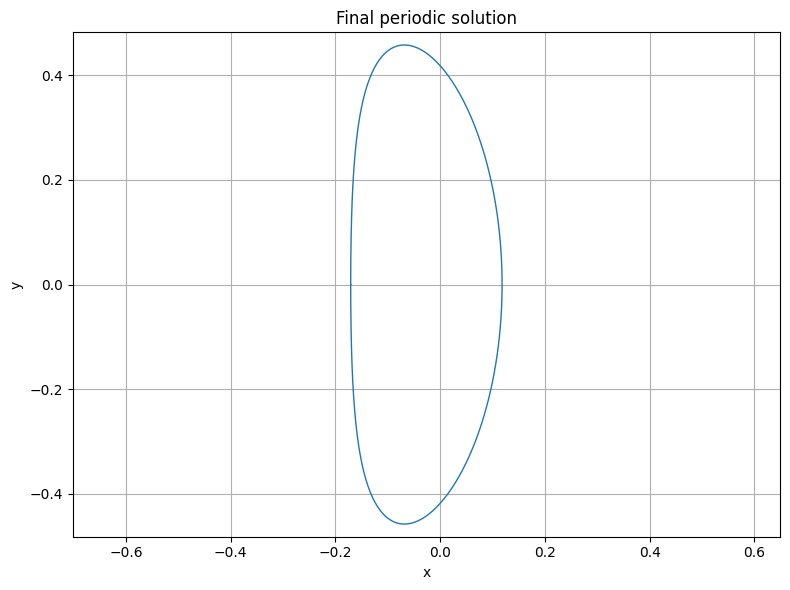

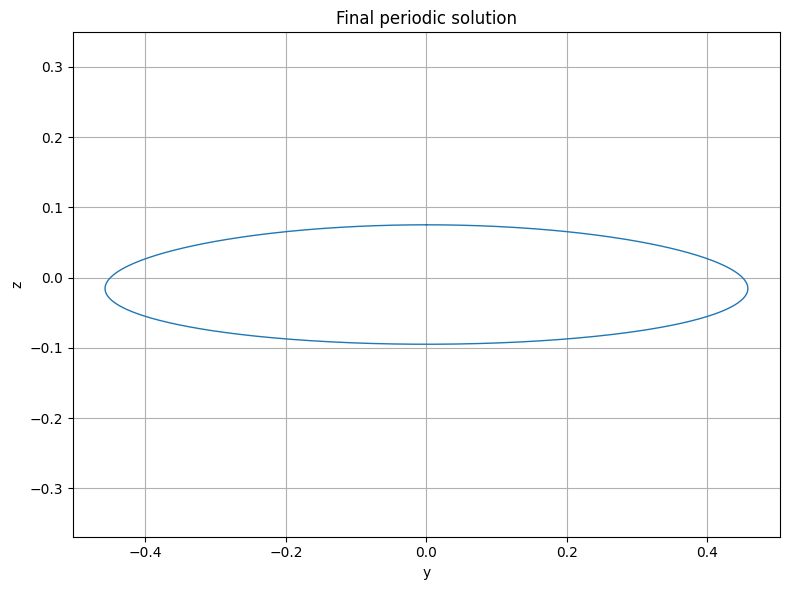

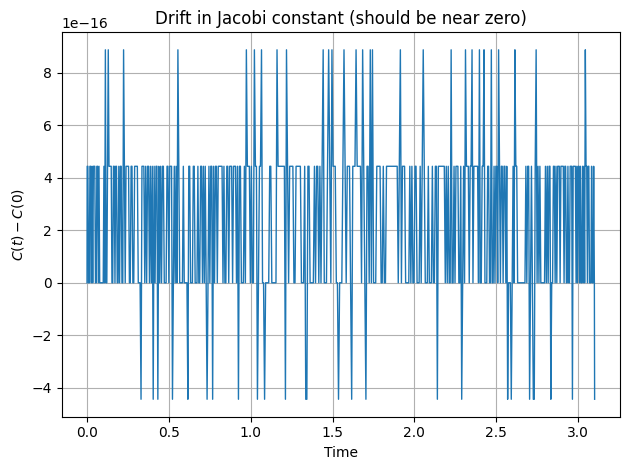

correction: [ 4.30837688e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -1.28739900e-04 -0.00000000e+00]
error after one period: 3.868734045978166e-11


In [18]:
def rtbp(t, state):
    x, y, z, u, v, w = state
    dx = u
    dy = v
    dz = w
    du = x + 2*v - ((1 - mu)*(x + mu))/(((x + mu)**2 + (y)**2 + (z)**2)**1.5) - ((mu*(x - 1 + mu)) / (((x - 1 + mu))**2 + (y)**2 + (z)**2)**1.5)
    dv = -2*u + y - ((1 - mu)*y)/(((x + mu)**2 + (y)**2 + (z)**2)**1.5) - (mu*y) / (((x - 1 + mu)**2 + (y)**2 + (z)**2)**1.5)
    dw = - ((1 - mu)*z) / (((x + mu)**2 + (y)**2 + (z)**2)**1.5) - (mu*z) / (((x -1 + mu)**2 + (y)**2 + (z)**2)**1.5)
    return [dx, dy, dz, du, dv, dw]

# Trying new initial condition

sol = solve_ivp(rtbp, (0.0, 2*t_half), corrected_guess, rtol=1e-14, atol=1e-15)

# Calculation of Jacobi constant

def jacobi_constant(state):
    """
    Compute Jacobi constant C = 2*Omega - (u^2+v^2+w^2) for a state in the CR3BP rotating frame.
    Inputs:
      - state: array-like of length 6 [x, y, z, u, v, w]
      - mu: mass parameter (float)
    Returns:
      - C: float, Jacobi constant
    """
    x, y, z, u, v, w = state
    r1 = np.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x - 1 + mu)**2 + y**2 + z**2)
    Omega = 0.5*(x**2 + y**2) + (1 - mu)/r1 + mu/r2
    C = 2*Omega - (u**2 + v**2 + w**2)
    return C

C_vals = np.array([jacobi_constant(sol.y[:, i]) for i in range(sol.y.shape[1])])

plt.figure(figsize=(8, 6))
plt.plot((sol.y[0] - 1 + mu - gamma)/gamma, sol.y[1]/gamma, linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Final periodic solution')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(sol.y[1]/gamma, sol.y[2]/gamma, linewidth=1)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Final periodic solution')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(sol.t, C_vals - jacobi_constant(sol.y[:, 0]), linewidth=1)
plt.xlabel("Time")
plt.ylabel("$C(t) - C(0)$")
plt.title("Drift in Jacobi constant (should be near zero)")
plt.grid(True)
plt.tight_layout()
plt.show()

print('correction:', X0 - corrected_guess)
print('error after one period:', np.linalg.norm(corrected_guess - sol.y[:, -1]))

# Coordinate transformation, putting L2 at (0,0,0)
X = (corrected_guess[0] - 1 + mu - gamma) / gamma
Y = corrected_guess[1] / gamma
Z = corrected_guess[2] / gamma
U = corrected_guess[3] / gamma
V = corrected_guess[4] / gamma
W = corrected_guess[5] / gamma

initial_condition = np.array([X, Y, Z, U, V, W])
period = 2*t_half

In [19]:
# Monodromy matrix calculation
X0 = np.array(corrected_guess, dtype=float)
phi0 = np.eye(6).reshape(36)
state0 = np.hstack((X0, phi0))
sol = solve_ivp(cr3bp_equations, [0,period], state0,
                rtol=1e-12, atol=1e-14)
Phi = sol.y[6:42,-1].reshape((6,6))
print(Phi)

eigvals, eigvecs = np.linalg.eig(Phi)
print("eigenvalues:", eigvals)
print("eigenvector for eigvals[0]:", eigvecs[:, 0])

[[ 1.24451307e+03 -4.29548026e+01  8.01275983e+01  2.59190961e+02
   2.29632749e+02  1.11814522e+01]
 [-1.10464775e+03  3.90523993e+01 -7.11001734e+01 -2.29632749e+02
  -2.04088102e+02 -9.91456075e+00]
 [ 5.36690070e+01 -1.89369722e+00  4.45609517e+00  1.11814521e+01
   9.91456071e+00  3.94783960e-01]
 [ 3.77163163e+03 -1.29967061e+02  2.43043509e+02  7.85247567e+02
   6.96471546e+02  3.38398856e+01]
 [-2.28095428e+03  7.88097106e+01 -1.46975657e+02 -4.75427121e+02
  -4.20213099e+02 -2.04692071e+01]
 [ 3.85243855e+02 -1.32795400e+01  2.48358091e+01  8.01275981e+01
   7.11001731e+01  4.45609517e+00]]
eigenvalues: [1.65351979e+03+0.j        6.04770508e-04+0.j
 9.95865072e-01+0.0908447j 9.95865072e-01-0.0908447j
 9.99987756e-01+0.j        1.00001224e+00+0.j       ]
eigenvector for eigvals[0]: [ 0.26328182+0.j -0.23353912+0.j  0.01136078+0.j  0.79758939+0.j
 -0.4829322 +0.j  0.08149079+0.j]


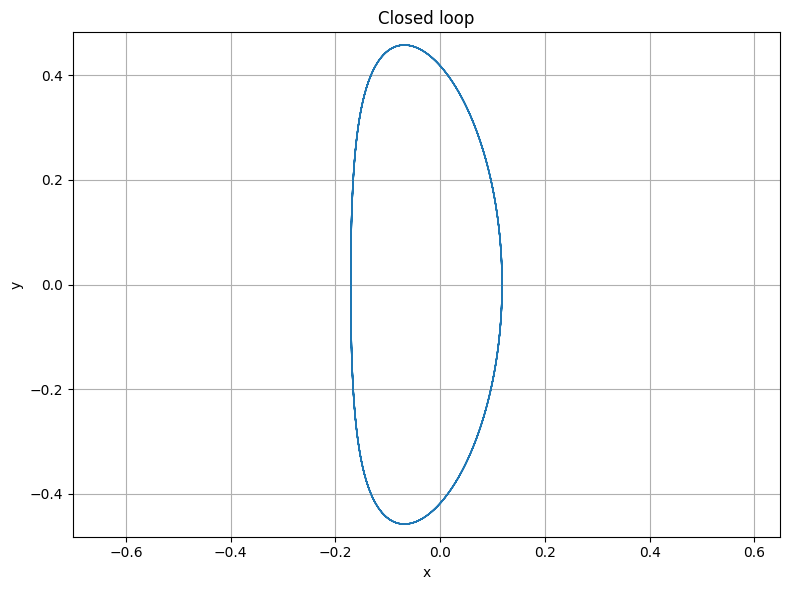

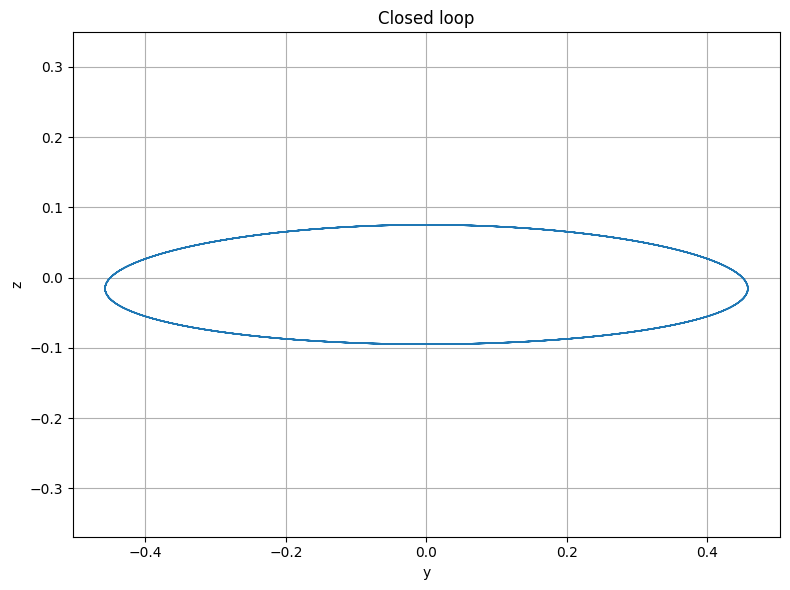

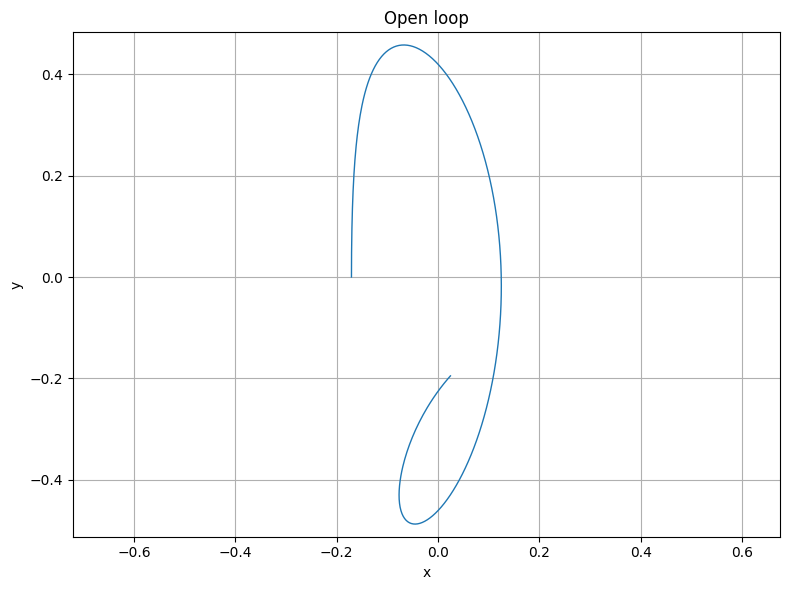

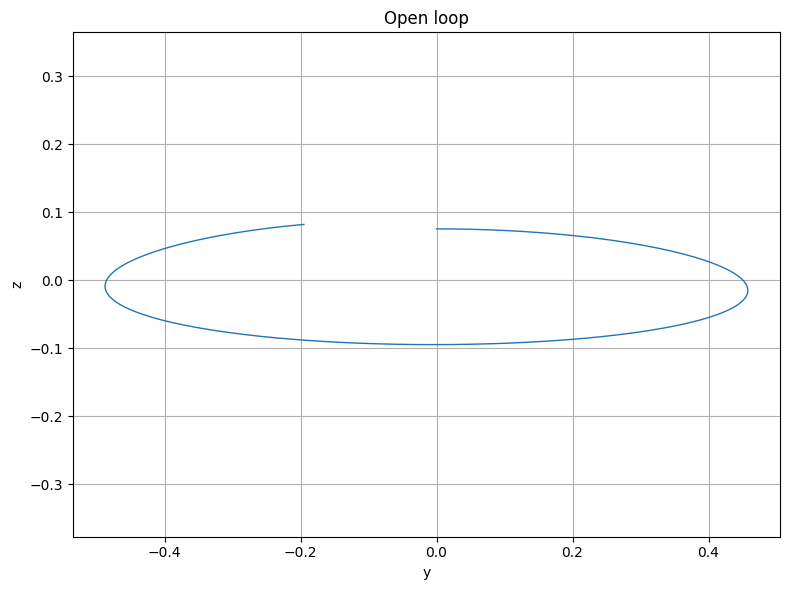

Delta v (km/s): 0.00039888050074665015


In [20]:
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
from scipy.interpolate import interp1d

def cr3bp_state(t, state):
    x, y, z, u, v, w = state
    dx = u
    dy = v
    dz = w
    du = x + 2*v + (1 - mu)/gamma + 1 - ((1 - mu)*(x + 1 + 1/gamma))/(((gamma*(x + 1) + 1)**2 + (gamma*y)**2 + (gamma*z)**2)**1.5) - ((mu*(x + 1)) / (((gamma*(x + 1))**2 + (gamma*y)**2 + (gamma*z)**2)**1.5))
    dv = -2*u + y - ((1 - mu)*y)/(((gamma*(x + 1) + 1)**2 + (gamma*y)**2 + (gamma*z)**2)**1.5) - (mu*y) / (((gamma*(x + 1))**2 + (gamma*y)**2 + (gamma*z)**2)**1.5)
    dw = - ((1 - mu)*z) / (((gamma*(x + 1) + 1)**2 + (gamma*y)**2 + (gamma*z)**2)**1.5) - (mu*z) / (((gamma*(x + 1))**2 + (gamma*y)**2 + (gamma*z)**2)**1.5)
    return [dx, dy, dz, du, dv, dw]

def A_matrix(state):
    x, y, z, vx, vy, vz = state
    r1 = np.sqrt((gamma*(x + 1) + 1)**2 + (gamma*y)**2 + (gamma*z)**2)
    r2 = np.sqrt((gamma*(x + 1))**2 + (gamma*y)**2 + (gamma*z)**2)

    Uxx = 1 - (1 - mu)/r1**3 * (1 - 3*(gamma*(x + 1) + 1)**2/r1**2) - mu/r2**3 * (1 - 3*(gamma*(x + 1))**2/r2**2)
    Uyy = 1 - (1 - mu)/r1**3 * (1 - 3*(gamma*y)**2/r1**2)          - mu/r2**3 * (1 - 3*(gamma*y)**2/r2**2)
    Uzz =    - (1 - mu)/r1**3 * (1 - 3*(gamma*z)**2/r1**2)          - mu/r2**3 * (1 - 3*(gamma*z)**2/r2**2)
    Uxy = 3*((1 - mu)*(gamma*(x + 1) + 1)*gamma*y/r1**5 + mu*(x + 1)*gamma**2*y/r2**5)
    Uxz = 3*((1 - mu)*(gamma*(x + 1) + 1)*gamma*z/r1**5 + mu*(x + 1)*gamma**2*z/r2**5)
    Uyz = 3*((1 - mu)*gamma**2*y*z/r1**5 + mu*gamma**2*y*z/r2**5)

    A = np.zeros((6,6))
    A[0,3] = 1
    A[1,4] = 1
    A[2,5] = 1

    A[3,0], A[3,1], A[3,2], A[3,4] = Uxx, Uxy, Uxz, 2
    A[4,0], A[4,1], A[4,2], A[4,3] = Uxy, Uyy, Uyz, -2
    A[5,0], A[5,1], A[5,2]         = Uxz, Uyz, Uzz

    return A

B = np.zeros((6,3))
B[3,0] = 1.0
B[4,1] = 1.0
B[5,2] = 1.0

N = 100
t_grid = np.linspace(0.0, period, N)

sol = solve_ivp(lambda t,y: cr3bp_state(t,y), [0, period], initial_condition, t_eval=t_grid, rtol=1e-12, atol=1e-12)
x_nom = sol.y.T

# Definition of cost matrices
Q = np.diag([1e0, 1e0, 1e0, 1e-1, 1e-1, 1e-1])
R = np.eye(3) * 1e-2

K_list = np.zeros((N, 3, 6))
P_list = np.zeros((N, 6, 6))

# Calculation of gains
for i in range(N):
    A = A_matrix(x_nom[i])
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.inv(R) @ B.T @ P
    P_list[i] = P
    K_list[i] = K

K_flat = K_list.reshape(N, -1).T   # shape (18, N)

K_interp_fn = interp1d(t_grid, K_flat, kind='linear', axis=1, fill_value='extrapolate')

# Gain scheduling
def K_of_t(t):
    """Return 3x6 gain at time t (handles t outside [0,period] by modulo)."""
    t_mod = np.mod(t, period)
    Kf = K_interp_fn(t_mod)
    return Kf.reshape((3,6))

x_nom_interp = interp1d(t_grid, x_nom.T, kind='cubic', axis=1)

def closed_loop_rhs(t, x):
    x_nom_t = x_nom_interp(np.mod(t, period))
    delta = x - x_nom_t
    Kt = K_of_t(t)
    u = - Kt.dot(delta)
    f = cr3bp_state(t, x)
    return f + B.dot(u)

# Initial state with small perturbation
x0_actual = initial_condition + 1e-3*np.array([0.0, 0.0, 0.0, 0.0, 1.0, 0.0])

sol_cl = solve_ivp(closed_loop_rhs, (0,5*period), x0_actual, rtol=1e-12, atol=1e-12)

plt.figure(figsize=(8, 6))
plt.plot(sol_cl.y[0], sol_cl.y[1], linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Closed loop')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(sol_cl.y[1], sol_cl.y[2], linewidth=1)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Closed loop')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

# Open loop response
sol = solve_ivp(cr3bp_state, (0.0, period), x0_actual, rtol=1e-12, atol=1e-12)

plt.figure(figsize=(8, 6))
plt.plot(sol.y[0], sol.y[1], linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Open loop')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(sol.y[1], sol.y[2], linewidth=1)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Open loop')
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

# Delta v calculation
def compute_delta_v(sol_cl, K_of_t, x_nom_interp, period):
    t = sol_cl.t
    x_traj = sol_cl.y.T
    u_norms = np.empty(len(t))

    for i, ti in enumerate(t):
        x_nom_t = x_nom_interp(np.mod(ti, period)).reshape(6,)
        delta = x_traj[i] - x_nom_t
        u = -K_of_t(ti).dot(delta)
        u_norms[i] = np.linalg.norm(u)

    delta_v = np.trapezoid(u_norms, t)
    return delta_v

delta_v = compute_delta_v(sol_cl, K_of_t, x_nom_interp, period)
print("Delta v (km/s):", delta_v * 1507674.1 / 5022635.5)